In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# 1. Load Data
url = "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"
data = pd.read_csv(url)

# Display first few rows
display(data.head())



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


FEATURE info
* tenure        : how long the customer has been with the company (numeric)
* Contract      : type of contract (Month-to-month, One year, Two year)
* MonthlyCharges: how much the customer pays each month (numeric)
* InternetService: type of internet service (DSL, Fiber optic, No)
* PaymentMethod : how the customer pays their bill
* TechSupport   : whether the customer has tech support add-on
* Churn         : target variable (Yes / No) -> we want to predict this

In [2]:
# 2. Select Features
# Choose four features from the following list (or use all of them) to predict Churn
selected_features = [
    'tenure', 'Contract', 'MonthlyCharges',
    'InternetService', 'PaymentMethod', 'TechSupport', 'Churn'
]

df = data[selected_features].copy()
display(df.head())





,tenure,Contract,MonthlyCharges,InternetService,PaymentMethod,TechSupport,Churn
0,1,Month-to-month,29.85,DSL,Electronic check,No,No
1,34,One year,56.95,DSL,Mailed check,No,No
2,2,Month-to-month,53.85,DSL,Mailed check,No,Yes
3,45,One year,42.30,DSL,Bank transfer (automatic),Yes,No
4,2,Month-to-month,70.70,Fiber optic,Electronic check,No,Yes


In [3]:
# =======================================================
# STEP 3: Data Preprocessing + Split data into X and y
# ======================================================
# Encode target variable
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Handle missing values
df.dropna(inplace=True)

# Encode categorical variables
categorical_cols = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport"
]

encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

# Split data into X and y
X = df.drop(columns=["Churn"])
y = df["Churn"]

print(X.head())
print(y.head())

   tenure  Contract  MonthlyCharges  InternetService  PaymentMethod  \
0       1         0           29.85                0              2   
1      34         1           56.95                0              3   
2       2         0           53.85                0              3   
3      45         1           42.30                0              0   
4       2         0           70.70                1              2   

   TechSupport  
0            0  
1            0  
2            0  
3            2  
4            0  
0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [4]:
# ==========================================
# STEP 4: Train-Test Split
# ==========================================
# random_state number ensures the split is reproducible every run.
# stratify=y keeps the same churn ratio in both train and test sets,which is important because the dataset is imbalanced.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 5634
Testing samples: 1409


In [5]:

# ==========================================
# STEP 5: Model Training with GridSearchCV
# ==========================================

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)


Best Parameters:
{'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 5}


In [6]:

# ==========================================
# STEP 6: Model Evaluation
# ==========================================
# TODO: Predict on X_test and calculate Accuracy, Precision, Recall, and F1-score

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1-score :", round(f1,4))



Accuracy : 0.7885
Precision: 0.608
Recall   : 0.5722
F1-score : 0.5895


           Feature  Importance
1         Contract    0.490300
2   MonthlyCharges    0.264845
0           tenure    0.165804
3  InternetService    0.027815
4    PaymentMethod    0.026209
5      TechSupport    0.025026


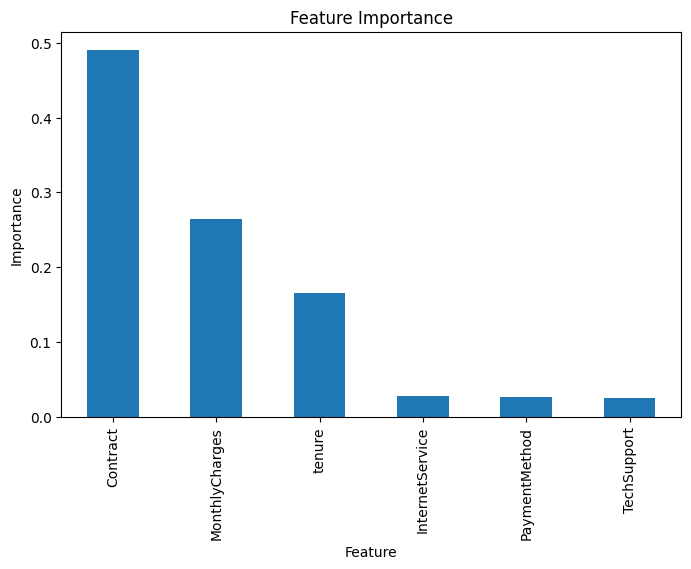

In [8]:

# ==========================================
# STEP 7: Feature Importance
# ==========================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()


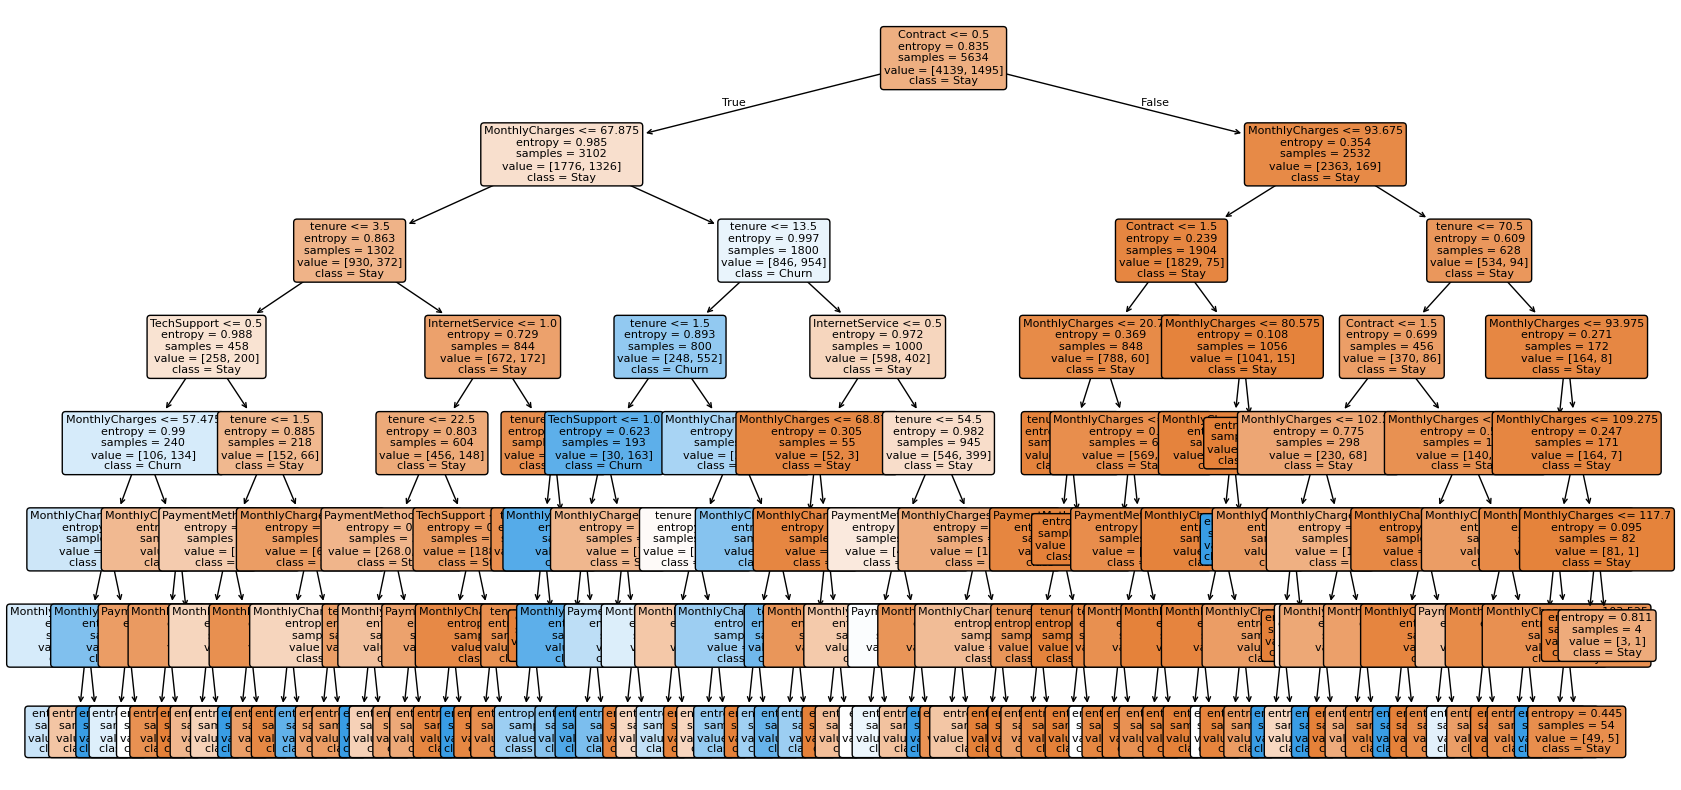

In [9]:

# ==========================================
# STEP 8: Decision Tree Visualization
# ==========================================
# TODO: Use plot_tree() to visualize your trained Decision Tree

plt.figure(figsize=(20,10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Stay", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()
